# ML Practical 2
# Name:- Devashish Tadaskar
# Roll no:- C-C2-25

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df=pd.read_csv("processes2.csv")

In [ ]:
df.head()


,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5,74.00,kmpl,23.40,1248
1,2,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5,90.00,kmpl,23.00,1396
2,4,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5,81.86,kmpl,20.14,1197
3,7,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5,67.10,kmpl,23.59,1364
4,8,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5,68.10,kmpl,20.00,1399


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2095 non-null   int64  
 1   name                2095 non-null   object 
 2   year                2095 non-null   int64  
 3   selling_price       2095 non-null   int64  
 4   km_driven           2095 non-null   int64  
 5   fuel                2095 non-null   object 
 6   seller_type         2095 non-null   object 
 7   transmission        2095 non-null   object 
 8   owner               2095 non-null   object 
 9   seats               2095 non-null   int64  
 10  max_power (in bph)  2095 non-null   float64
 11  Mileage Unit        2095 non-null   object 
 12  Mileage             2095 non-null   float64
 13  Engine (CC)         2095 non-null   int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 229.3+ KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
seats,0


In [ ]:
df.duplicated().sum()

np.int64(0)

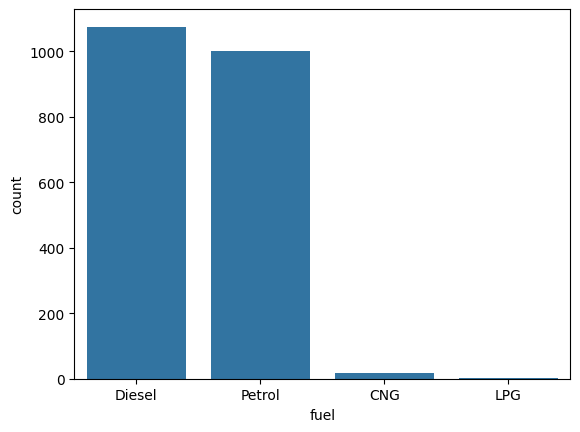

In [ ]:
sns.countplot(x=df["fuel"])
plt.show()

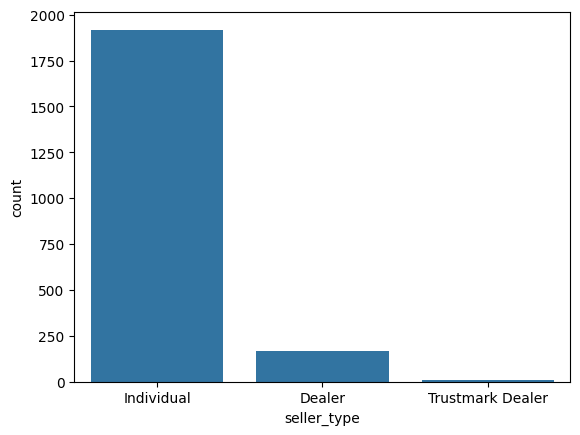

In [ ]:
sns.countplot(x=df["seller_type"])
plt.show()

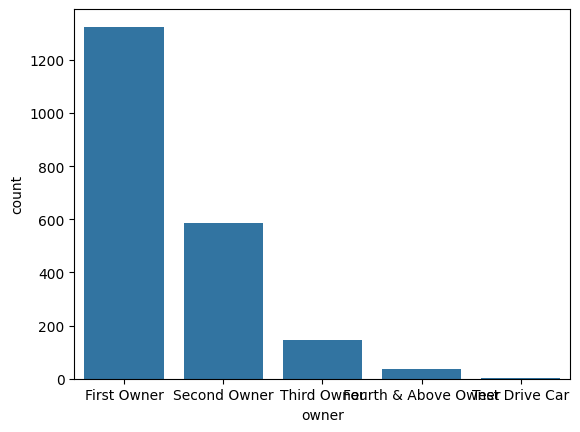

In [ ]:
sns.countplot(x=df["owner"])
plt.show()

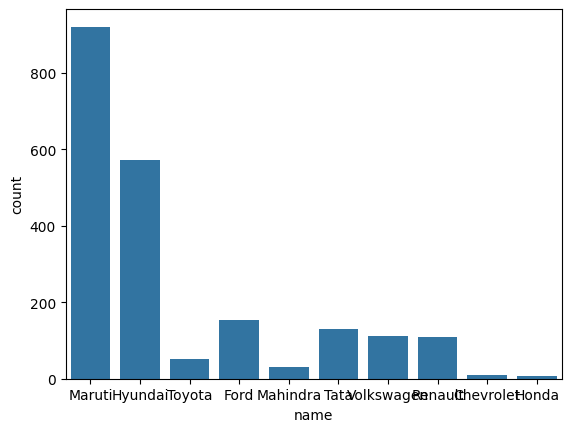

In [ ]:
sns.countplot(x=df["name"])
plt.show()

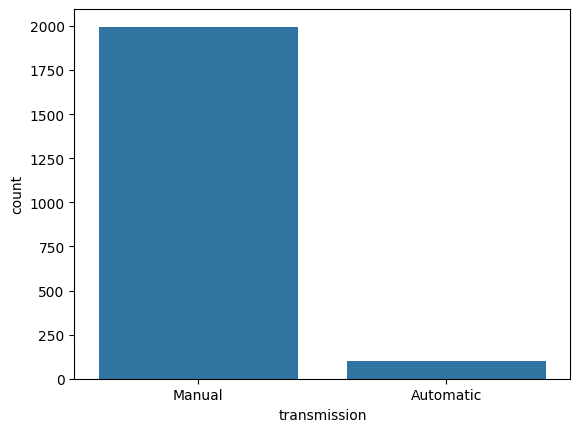

In [ ]:
sns.countplot(x=df["transmission"])
plt.show()

In [ ]:
le=LabelEncoder()
df["fuel"]=le.fit_transform(df["fuel"])
df["transmission"]=le.fit_transform(df["transmission"])
df["seller_type"]=le.fit_transform(df["seller_type"])
df["owner"]=le.fit_transform(df["owner"])

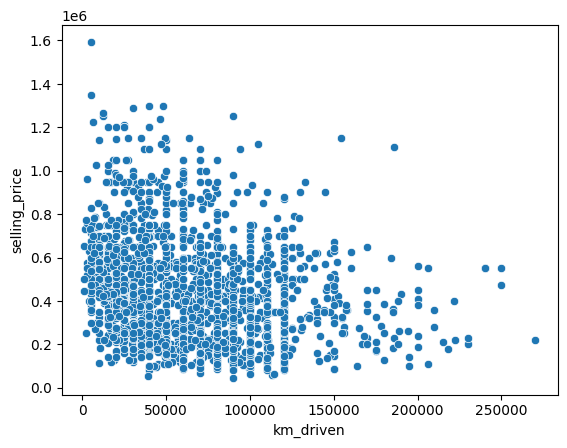

In [ ]:
sns.scatterplot(x="km_driven",y="selling_price",data=df)
plt.show()

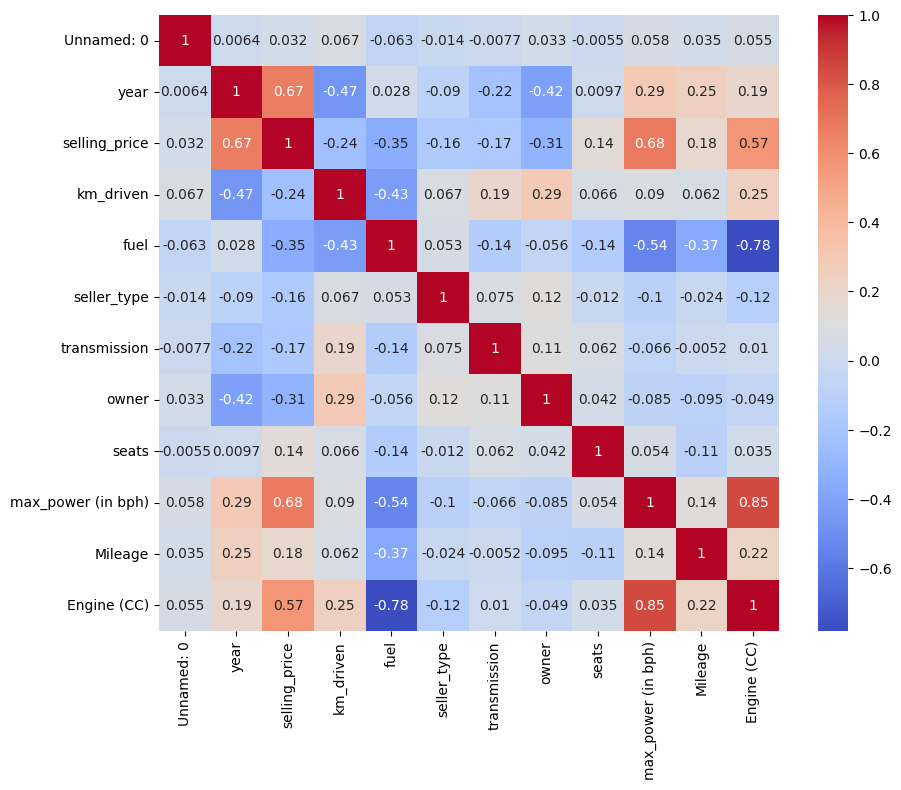

In [ ]:

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])



sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

Intercept: 525857.5687858235
Slope: -1.3798492259984105
Mean Squared Error: 46205796007.29743
R² Score: 0.022512917274240096


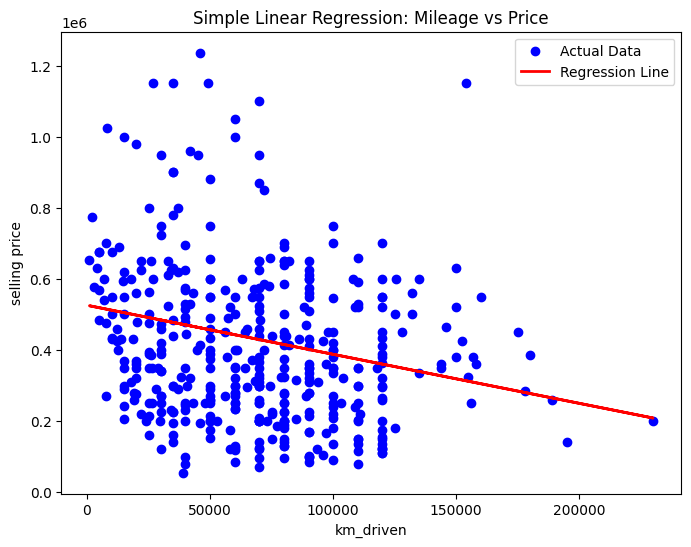

In [ ]:
# Select dependent and independent variable
x=df[['km_driven']]
y=df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)

print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_[0])


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("km_driven")
plt.ylabel("selling price")
plt.title("Simple Linear Regression: Mileage vs Price")
plt.legend()
plt.show()

## Multiple Regression

In [ ]:
y = df["selling_price"]
X = df[[ "fuel", "transmission", "km_driven", "Mileage","seller_type","owner","seats","Engine (CC)"]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mr = LinearRegression()
mr.fit(X_train, y_train)


y_pred = mr.predict(X_test)

print("Intercept:", mr.intercept_)

print("\nCoefficients:")
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mr.coef_
})
print(coefficients)

print("\nR² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Intercept: -919242.3574131159

Coefficients:
        Feature   Coefficient
0          fuel  17973.819833
1  transmission -94545.730053
2     km_driven     -1.829234
3       Mileage  16772.261347
4   seller_type -30772.862124
5         owner -31775.749055
6         seats  86043.191750
7   Engine (CC)    652.208505

R² Score: 0.5681351802707824
Mean Squared Error: 20414241902.2993


### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
lr=LinearRegression()

In [ ]:
lr_parms = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

In [ ]:
grid_search = GridSearchCV(
    estimator = lr,
    param_grid = lr_parms,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [ ]:
print("Best Parameters: ")
print(grid_search.best_params_)

Best Parameters: 
{'fit_intercept': True, 'positive': False}


In [ ]:
{'fit_intercept': True, 'positive': False}

{'fit_intercept': True, 'positive': False}

In [ ]:
print(": Best Cross Validation Score : ")
print(grid_search.best_score_)

: Best Cross Validation Score : 
0.5349160675378217


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
LinearRegression(fit_intercept=True,
                 positive=False)

LinearRegression()

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 105367.65434441924
Mean Squared Error: 20414241902.2993
Root Mean Squared Error: 142878.416502631
R² Score: 0.5681351802707824


In [ ]:
print(best_model)

LinearRegression()


In [ ]:
results = grid_search.cv_results_

for mean_score, params in zip(results['mean_test_score'], results['params']):
    print(params, "R2 Score:", round(mean_score,4))

{'fit_intercept': True, 'positive': True} R2 Score: 0.3849
{'fit_intercept': True, 'positive': False} R2 Score: 0.5349
{'fit_intercept': False, 'positive': True} R2 Score: 0.281
{'fit_intercept': False, 'positive': False} R2 Score: 0.5203


### Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R2 Score:", r2_score(y_test, ridge_pred))

Default Ridge R2 Score: 0.5680745447191102


In [ ]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [ ]:
grid_ridge = GridSearchCV(
    estimator = ridge,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [ ]:
grid_ridge.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [ ]:
print("Best Alpha :",grid_ridge.best_params_)

Best Alpha : {'alpha': 1}


In [ ]:
print(grid_ridge.best_score_)

0.5349229616899345


In [ ]:
print("MAE :",mean_absolute_error(y_test, ridge_pred))
print("MSE :",mean_squared_error(y_test, ridge_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score :",r2_score(y_test, ridge_pred))

MAE : 105370.6700400905
MSE : 20417108143.685875
RMSE : 142888.44650175842
R2 Score : 0.5680745447191102


### LASSO Regression

In [ ]:
from sklearn.linear_model import Lasso

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

In [ ]:
grid_lasso = GridSearchCV(
    estimator = Lasso(),
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [ ]:
grid_lasso.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [ ]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [ ]:
lasso_pred = grid_lasso.predict(X_test)
print("Default Lasso R2 Score:", r2_score(y_test, lasso_pred))

Default Lasso R2 Score: 0.5681351803818258
